In [2]:
# reading the retail data set
retail <- read.csv("OnlineRetail.csv")

## Structure of `retail` dataset

In [3]:
str(retail)

'data.frame':	541909 obs. of  8 variables:
 $ InvoiceNo  : chr  "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr  "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr  "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : int  6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: chr  "12/1/2010 8:26" "12/1/2010 8:26" "12/1/2010 8:26" "12/1/2010 8:26" ...
 $ UnitPrice  : num  2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : int  17850 17850 17850 17850 17850 17850 17850 17850 17850 13047 ...
 $ Country    : chr  "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...


In [4]:
df <- data.frame(retail)

## Data Cleaning Plan

- Handle missing Customer IDs:
  - Replace with `"Unknown"`
  - When I loaded that into `Microsoft SQL Server`, making primary key as `CustomerID` it throwed me an error, so it concluded that some of it's data are missing.

In [5]:
any(is.na(df$CustomerID)) 
df$CustomerID[is.na(df$CustomerID)] <- "Unknown"
any(is.na(df$CustomerID)) 

[1] TRUE

[1] FALSE

In [6]:
any(is.na(df)) # We have no missing values in our data frame

[1] FALSE

# COUNTRY NAME NORMALIZATION SCRIPT

---

## Purpose
Clean and standardize country names in a dataset using the **countrycode** library.  
Handles exceptions, islands, and regional/unspecified categories separately.

---

## Steps
1. Convert country names to ISO3 codes using `countrycode`.  
2. Preserve known abbreviations or special entries (e.g. `USA`, `RSA`, `EIRE`).  
3. Group island-related and unspecified entries into categories.  
4. Split dataset into:
   - **specified_country** → valid countries  
   - **other_category** → islands, unspecified, or regional groups  

---

## Libraries
- `countrycode`  
- `dplyr`


In [7]:
library(countrycode)
library(dplyr) 
# Normalize the country name, and there are other's like islands specify them in different category

countryName <- function(country) { # since I don't like writing all code at single line
    countrycode(country, origin = "country.name", destination = "iso3c")
}

exception <- c("USA", "RSA", "EIRE", "Unspecified", "European Community", "Channel Islands")

# c("USA", "RSA", "EIRE", "Unspecified", "European Community", "Channel Islands"), these weird syntax drive me nuts its just inline condition condition ? smt else : smth
df$Country <- ifelse(df$Country %in% exception, df$Country, countryName(df$Country))

unique(df$Country)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“Some values were not matched unambiguously: Channel Islands, EIRE, European Community, RSA, Unspecified
”


[1] "GBR"                "FRA"                "AUS"               
 [4] "NLD"                "DEU"                "NOR"               
 [7] "EIRE"               "CHE"                "ESP"               
[10] "POL"                "PRT"                "ITA"               
[13] "BEL"                "LTU"                "JPN"               
[16] "ISL"                "Channel Islands"    "DNK"               
[19] "CYP"                "SWE"                "AUT"               
[22] "ISR"                "FIN"                "BHR"               
[25] "GRC"                "HKG"                "SGP"               
[28] "LBN"                "ARE"                "SAU"               
[31] "CZE"                "CAN"                "Unspecified"       
[34] "BRA"                "USA"                "European Community"
[37] "MLT"                "RSA"

## QUANTITY COLUMN VALIDATION AND CLEANUP


* **Source:** Based on backend experience, this transactional data is typically recorded **upon successful API transaction completion**. Manual entry is generally **not feasible** for e-commerce scale.
* **Negative Values:** The presence of multiple negative values is a key observation. These are **unlikely to be accidental entries**.
* **Interpretation:** Negative values most likely represent **canceled orders, refunds, or returns**.


In [8]:
# what might that -ve indicate, maybe cancelled order or the person doing the entry is drunk or he might have a thumb so big is enters everything incorrectly 
# if the transaction happens, and after the success the server of this website writes this data in csv then, -ve sign might indicate maybe a cancelled order or something

paste("Quantity with exact zero: ",  sum(df[df$Quantity == 0]), " Quantity with non negative: ", sum(df$Quantity)) # we expect larger number than the dim of df, cause more than one items can be sold
nv <- df[df$Quantity < 0, ]
df <- df[df$Quantity > 0, ] # those are canceled order or refunded we will do seprate analysis on that


[1] "Quantity with exact zero:  0  Quantity with non negative:  5176450"

## Checking for StockCode

In [9]:
any(is.na(df$StockCode)) # We don't have any nulls in stock code.
any(df$StockCode <= 0)

[1] FALSE

[1] FALSE

# UNIT PRICE ERROR CHECK

---

## Purpose
Validate and clean the `UnitPrice` column to remove invalid or nonsensical values.

---

## Steps
1. Identify entries with `UnitPrice == 0` (2515 items).  
   - Attempt to impute using similar products if possible.  
   - Otherwise, drop these rows since their impact is minimal.

2. Remove rows with negative `UnitPrice` values.  
   - Found 2 cases with description *"Adjust bad debt"*, which were excluded.

---

## Result
All remaining entries now have valid positive `UnitPrice` values.


In [10]:
df <- df[df$UnitPrice > 0, ]
any(df$UnitPrice <= 0)
dim(df)

[1] FALSE

[1] 530104      8

## Product Description

In [11]:
check <- df[df$Description == "", ]
any(is.na(df$Description))
# I don't think we have an missing value over there

[1] FALSE

## Working with date 
    . From raw data, dates are given to us as a character, so we are converting it to date object.

In [12]:
df$InvoiceDate <- as.Date(df$InvoiceDate, format = "%m/%d/%Y") # %m represents month in decimal, %m represents month in decimal and %y represents the year 
str(df) # if we look at the str we should see the Date object, 

'data.frame':	530104 obs. of  8 variables:
 $ InvoiceNo  : chr  "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr  "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr  "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : int  6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: Date, format: "2010-12-01" "2010-12-01" ...
 $ UnitPrice  : num  2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : chr  "17850" "17850" "17850" "17850" ...
 $ Country    : chr  "GBR" "GBR" "GBR" "GBR" ...


## Exploratory Data Analysis

In [13]:
summary(df)
unique(df$Country)

  InvoiceNo          StockCode         Description           Quantity       
 Length:530104      Length:530104      Length:530104      Min.   :    1.00  
 Class :character   Class :character   Class :character   1st Qu.:    1.00  
 Mode  :character   Mode  :character   Mode  :character   Median :    3.00  
                                                          Mean   :   10.54  
                                                          3rd Qu.:   10.00  
                                                          Max.   :80995.00  
  InvoiceDate           UnitPrice          CustomerID          Country         
 Min.   :2010-12-01   Min.   :    0.001   Length:530104      Length:530104     
 1st Qu.:2011-03-28   1st Qu.:    1.250   Class :character   Class :character  
 Median :2011-07-20   Median :    2.080   Mode  :character   Mode  :character  
 Mean   :2011-07-04   Mean   :    3.908                                        
 3rd Qu.:2011-10-19   3rd Qu.:    4.130                      

[1] "GBR"                "FRA"                "AUS"               
 [4] "NLD"                "DEU"                "NOR"               
 [7] "EIRE"               "CHE"                "ESP"               
[10] "POL"                "PRT"                "ITA"               
[13] "BEL"                "LTU"                "JPN"               
[16] "ISL"                "Channel Islands"    "DNK"               
[19] "CYP"                "SWE"                "FIN"               
[22] "AUT"                "BHR"                "ISR"               
[25] "GRC"                "HKG"                "SGP"               
[28] "LBN"                "ARE"                "SAU"               
[31] "CZE"                "CAN"                "Unspecified"       
[34] "BRA"                "USA"                "European Community"
[37] "MLT"                "RSA"

## Most sold products

 Description        TotalItemSOldInGroup
 Length:5           Min.   :37891       
 Class :character   1st Qu.:48474       
 Mode  :character   Median :55047       
                    Mean   :60088       
                    3rd Qu.:78033       
                    Max.   :80995       

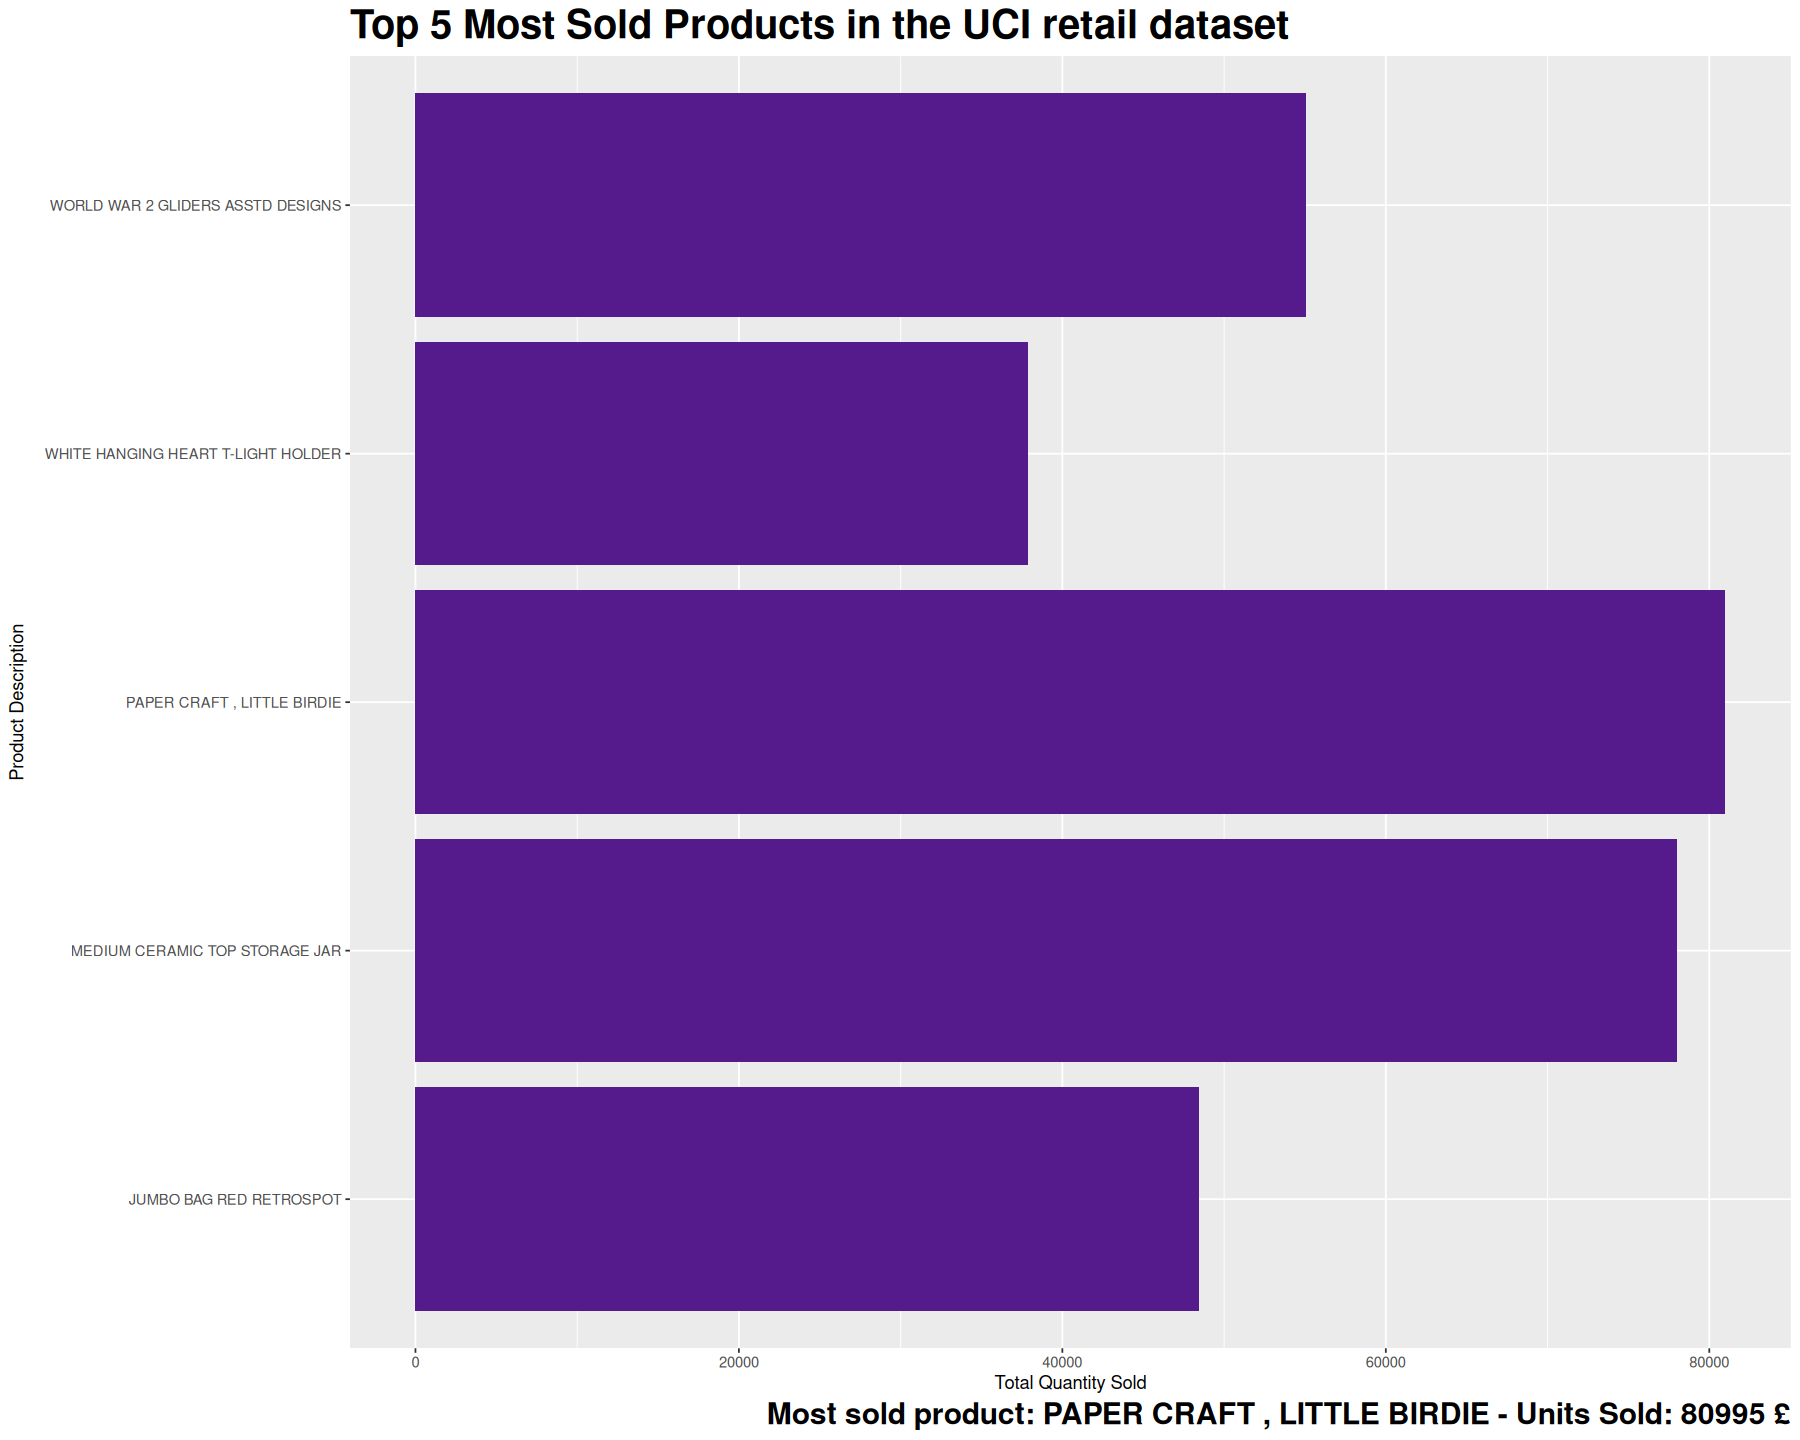

In [14]:
library(ggplot2)
options(repr.plot.width = 15, repr.plot.height = 12)
grouped_products <- group_by(df, Description) # takes and existing tbl and converts into a grouped tbl where opreations ar eperformed by group.
summarized_by_product <- summarise(grouped_products, TotalItemSOldInGroup = sum(Quantity, na.rm = TRUE)) # na.ram = TRUE means ignore missing values
# summarise forms a new table, where each group from group_by becomes one row
# /* Here, we have a large df like lets say
#    Product Qty
#    p1      1
#    p2      2
#    p1      1
#    group_by greats group, and sum does the summing of those, with na.rm ignoring values
#    p1      (1, 1)
#    p2      (2)
# */
ordered_by_product_sold <- summarized_by_product[order(summarized_by_product$TotalItemSOldInGroup, decreasing=TRUE), ] # why order because it gives the indices
top_5_items_sold <- head(ordered_by_product_sold, 5)

# stat="identity" meaning the value of the chart are directly determined by y-values, by default stat="count" uses height as frequency 
ggplot(top_5_items_sold, aes(x=Description, y=TotalItemSOldInGroup)) + geom_bar(stat = "identity", fill="purple4") +
labs(
    title = "Top 5 Most Sold Products in the UCI retail dataset",                             
    x = "Product Description",                          
    y = "Total Quantity Sold",
    caption = paste("Most sold product:", top_5_items_sold$Description[1], 
                    "- Units Sold:", top_5_items_sold$TotalItemSOldInGroup[1], "£") 
) +  coord_flip() + theme(
   plot.caption = element_text(size = 18, face = "bold"),
   plot.title = element_text(size=24, face="bold"),
) # it flips the barchart for better visibility
summary(top_5_items_sold)

## Number of sales over the years
    . Learning with trying
    . First I grouped by months and then realized that, it grouped let's say `month 1` of both the year and whole data is wrong
    . What we can do now is group by year first and then month and compare both the line plots.

    . First filter, by years, and then extract `months` and then make a line plot.
    . The above idea is rejected because the year 2010 has only 1 month of data.

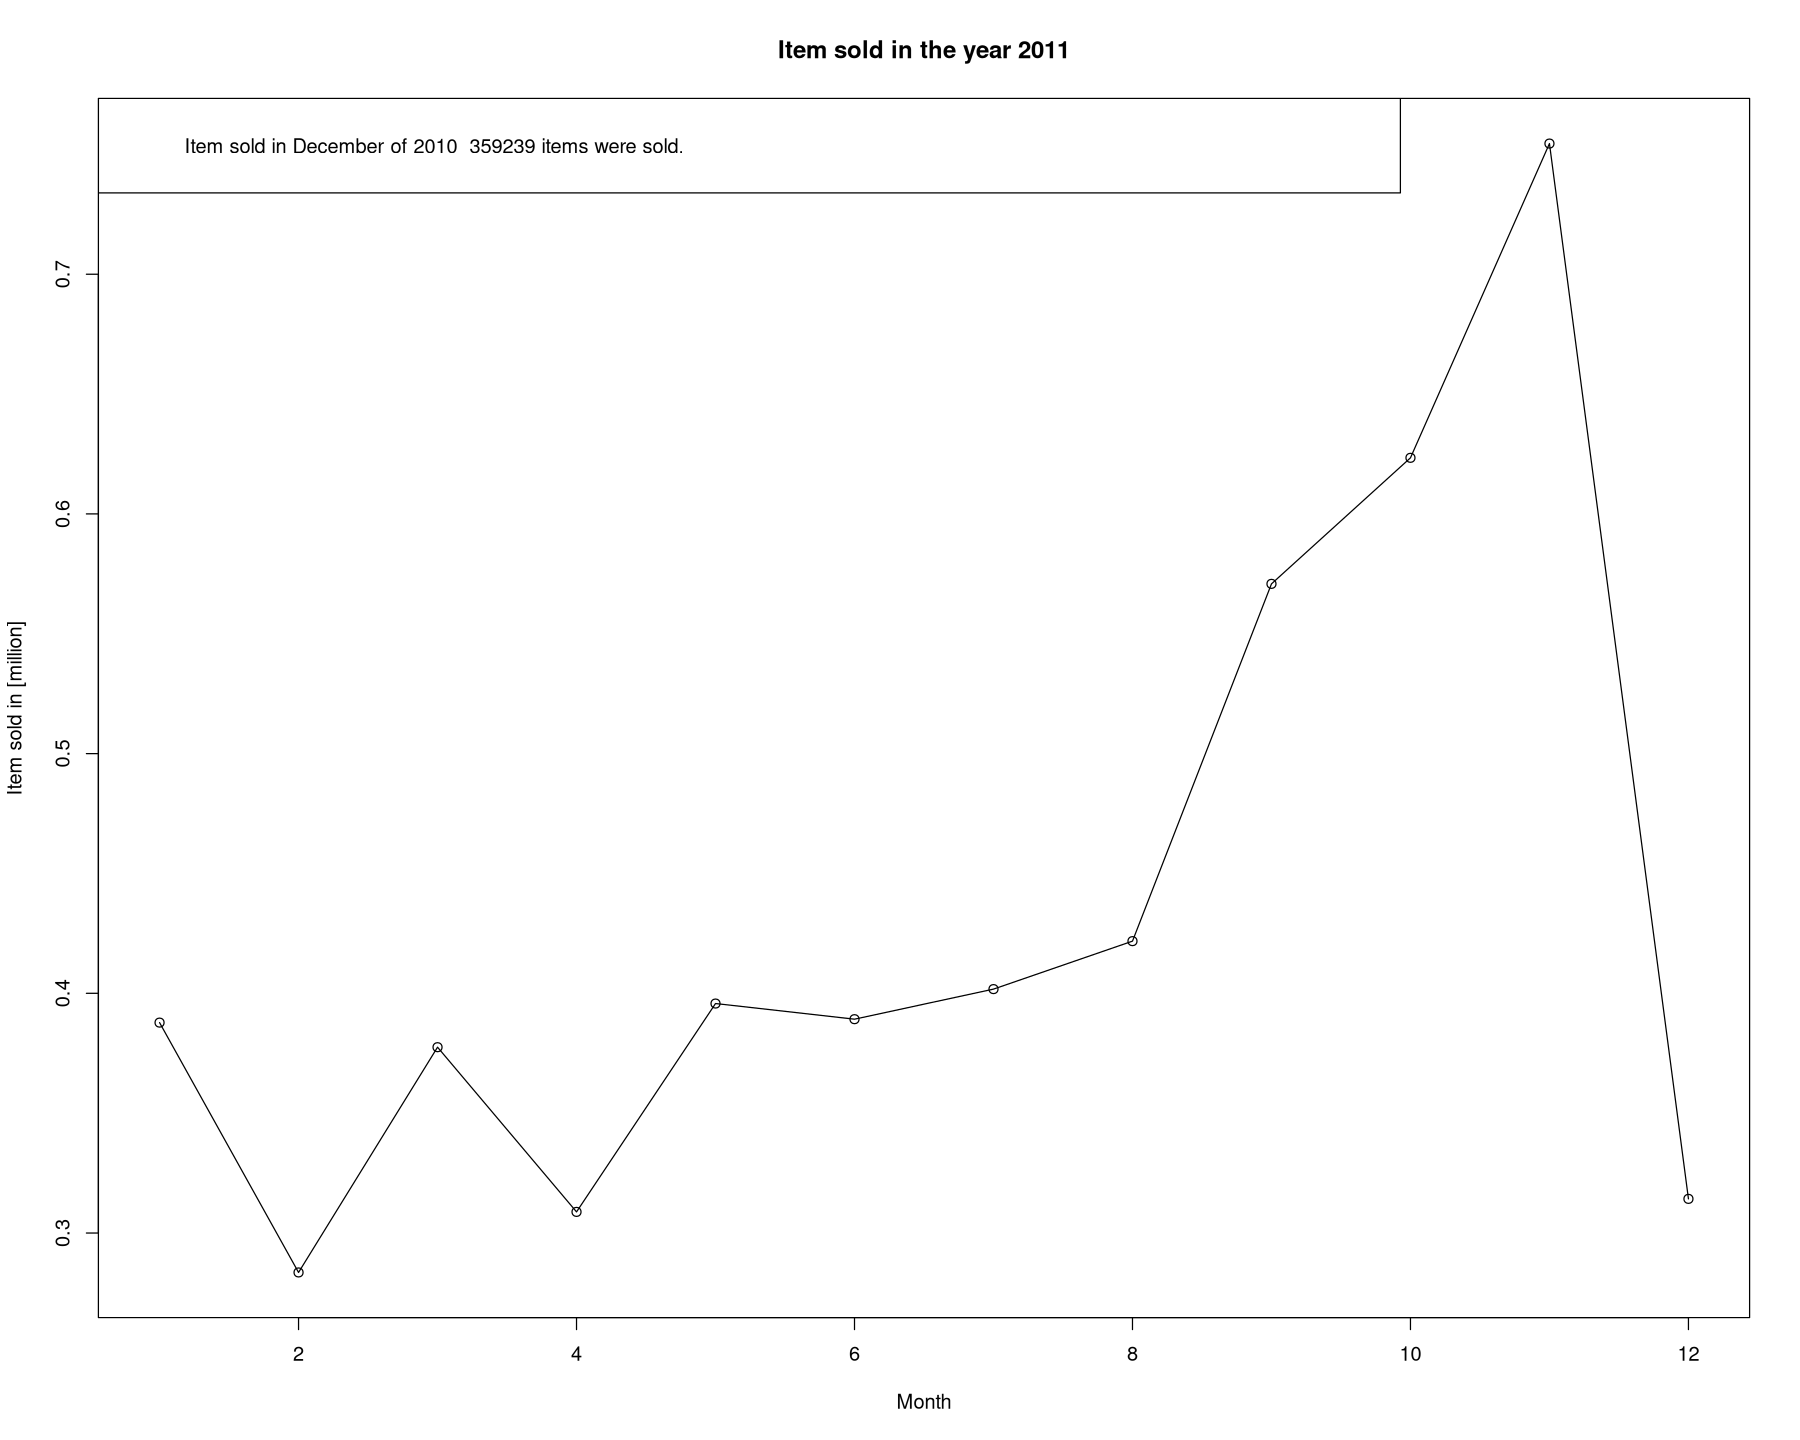

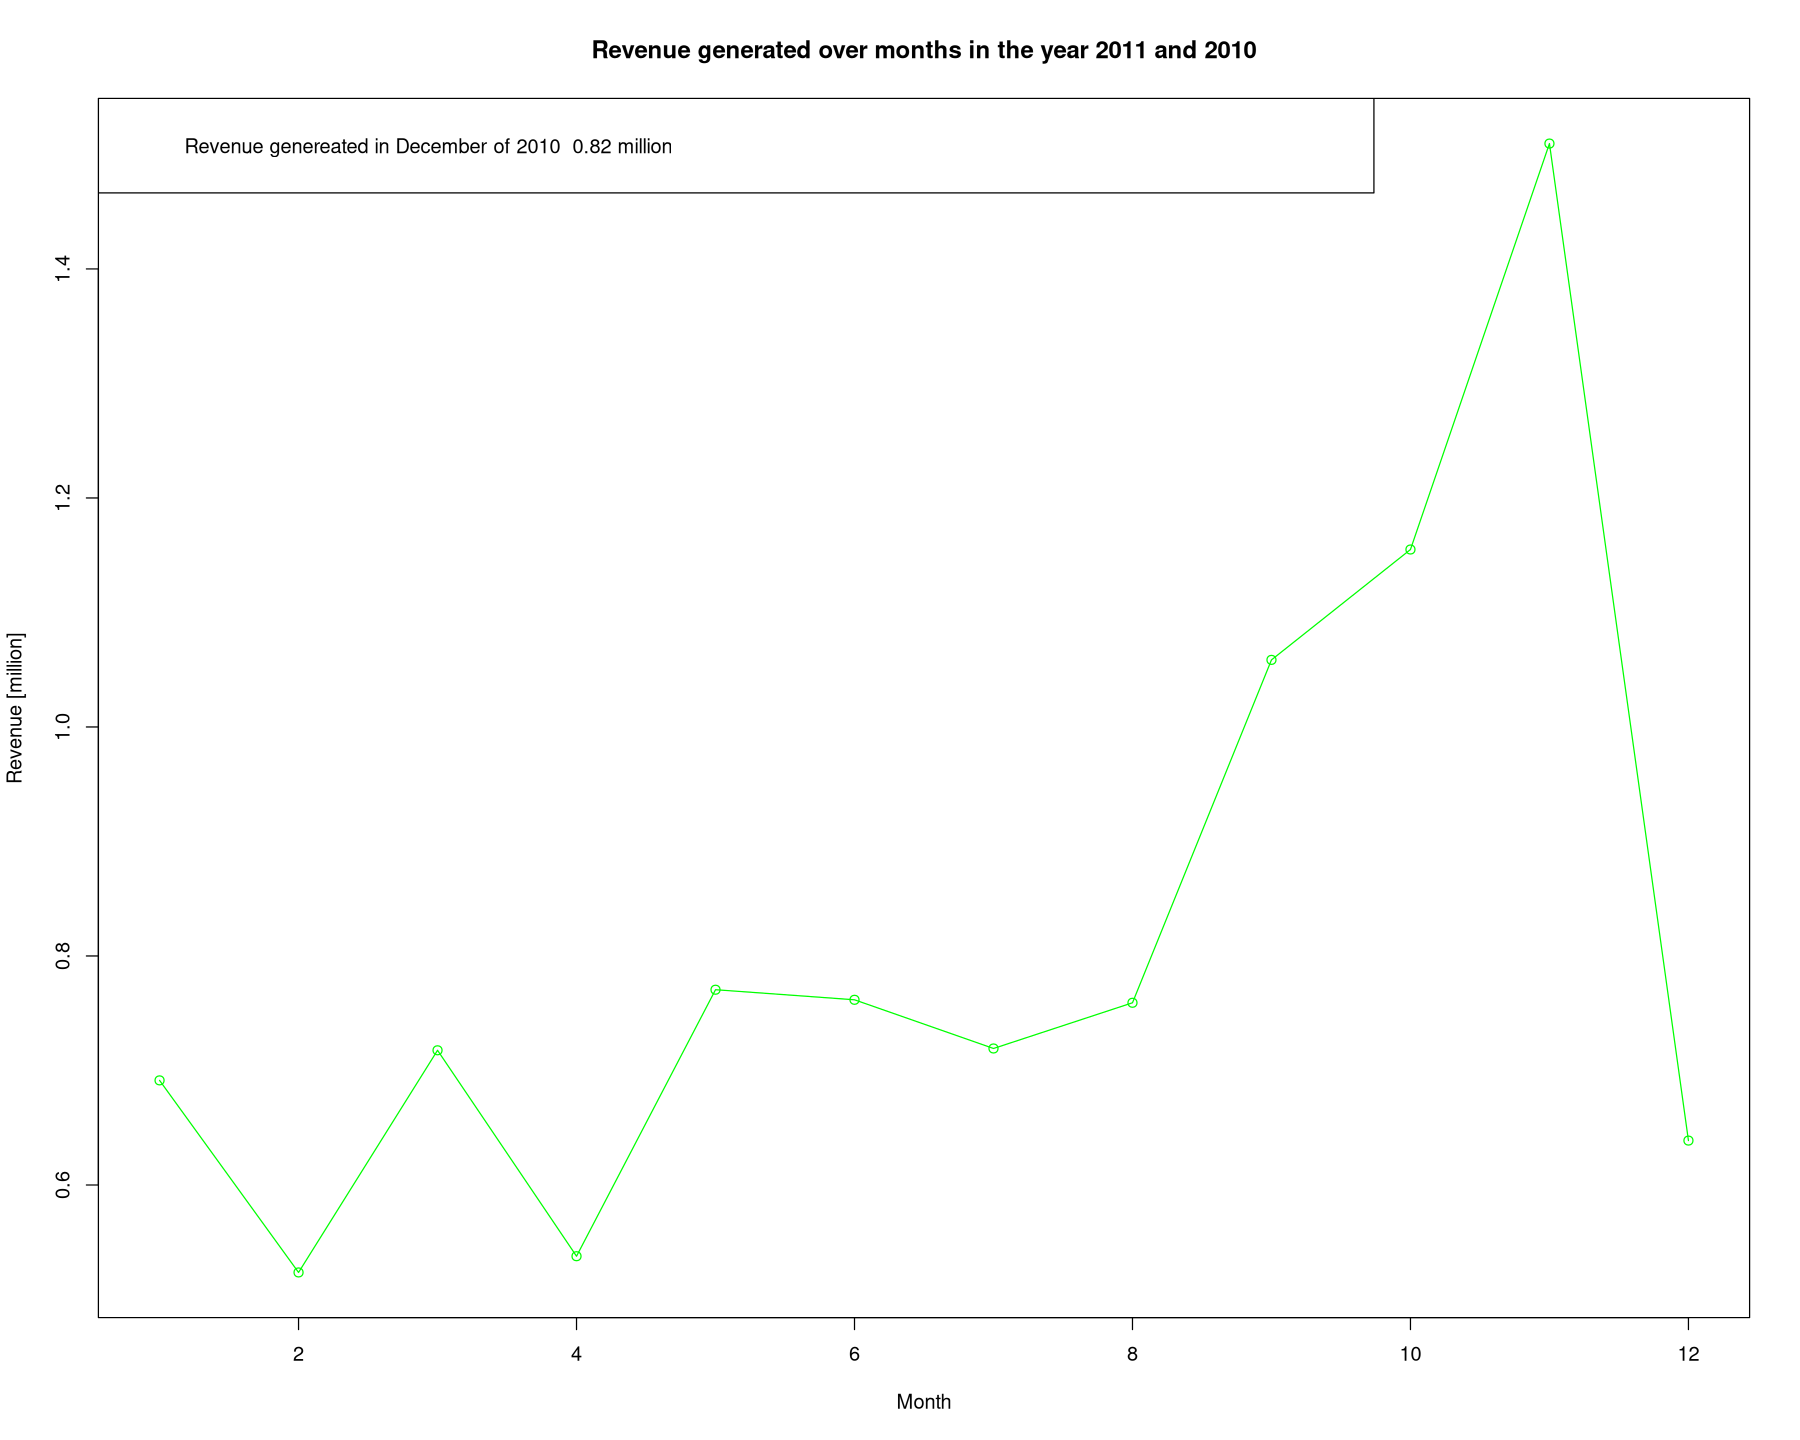

In [15]:
## I am new to this whole thing, but I know with practise I will leran to do things in better way, but now I will group that like done before.

library(dplyr)
library(ggplot2)

df$Year <- format(df$InvoiceDate, "%Y") # group by years okay 2010 and 2011 based on our data 
group_by_years <- group_by(df, Year) # It holds data which are grouped by years

group_by_month <- function(data_frame) {
    data_frame$Month <- format(data_frame$InvoiceDate, "%m") # adding a "month" column
    grouped_by_date <- group_by(data_frame, Month)
    # so far so good verified that 2010 has only 1 month data which is 12, I don't trust R
    # okay since the year 2010 has only 1 month of data we can't plot line graph and compare it like I did in my PID controller project. What we can do is create a bar chart for one 
    # and line chart for another year

    summ <- summarise(grouped_by_date, TotalItemSOldInGroup = sum(Quantity, na.rm = TRUE)) # I mean dataset is huge I expect it the item sold to be in more
    rev <- summarise(grouped_by_date, Rev = sum(Quantity * UnitPrice, na.rm = TRUE)) 
    return (list( Items_Sold_Summary = summ, Revenue_Summary = rev)) # don't want to regroup things so made it return in list, 
}
y10 <- filter(group_by_years, Year == "2010")
y11 <- filter(group_by_years, Year == "2011")
# Items sold in each month of the year
grouped_calc10 <- group_by_month(y10) # run time complexity will be more in the slow language so creating a varaible here
grouped_calc11 <- group_by_month(y11)

y10m <- grouped_calc10$Items_Sold_Summary
y11m <- grouped_calc11$Items_Sold_Summary

plot(y11m$Month, (y11m$TotalItemSOldInGroup/10^6), type="o", main ="Item sold in the year 2011", ylab="Item sold in [million]", xlab="Month")
# since 2010 has data for only one month
legend_label <- paste("Item sold in December of 2010 ", y10m$TotalItemSOldInGroup, "items were sold.")
legend("topleft", legend = c(legend_label))    

# revinue
y10r <- grouped_calc10$Revenue_Summary
y11r <- grouped_calc11$Revenue_Summary


# now let's plot down the revinue over the year
plot(y11r$Month, (y11r$Rev/10^6), type="o", main ="Revenue generated over months in the year 2011 and 2010", ylab="Revenue [million]", xlab="Month", col="green")
legend_label <- paste("Revenue genereated in December of 2010 ", signif(y10r$Rev/10^6, digits = 2), "million") # we want only two significant figures for human to read
legend("topleft", legend = c(legend_label))    

## Geographical Analysis: Revenue vs. Volume

tibble [5 × 2] (S3: tbl_df/tbl/data.frame)
 $ Country: chr [1:5] "GBR" "NLD" "EIRE" "DEU" ...
 $ Rev    : num [1:5] 9.025 0.285 0.283 0.229 0.21


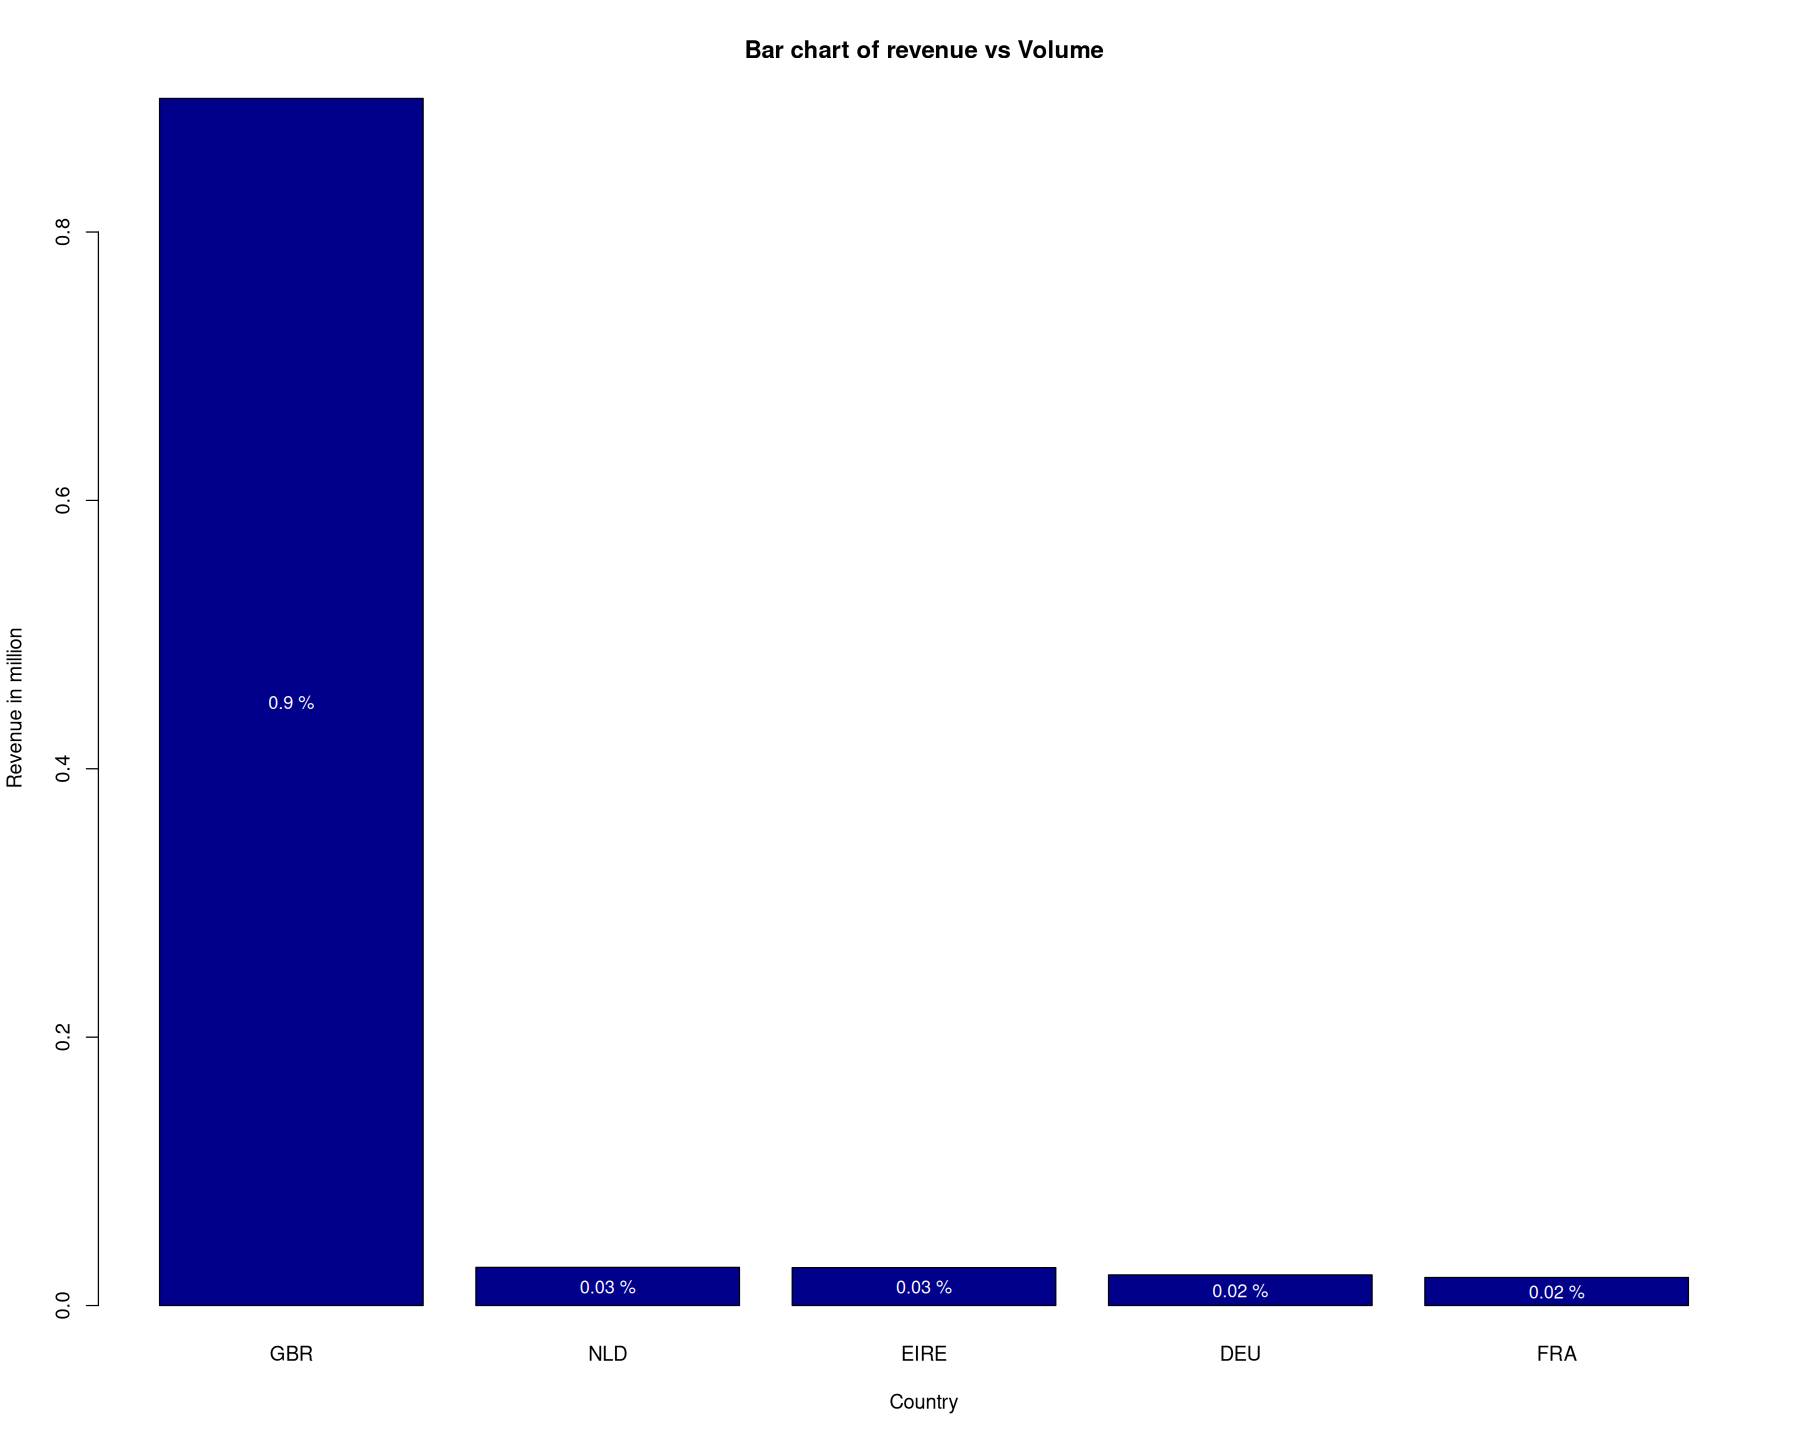

In [16]:
# The above code was messy, I am a beginner but let's try using pipe

library(dplyr)
# arrange(df, ex age) for decending order  arrange(df, desc(age))

top_5_revenue <- df %>%
  group_by(Country) %>%
  summarise(Rev = sum((UnitPrice * Quantity) / 10^6, na.rm = TRUE)) %>%
  arrange(desc(Rev)) %>%
  head(5)
str(top_5_revenue)
# I coudln't achive proper scaling of this, even though y="l"
rv_plot <- barplot(height = prop.table(top_5_revenue$Rev), names.arg = top_5_revenue$Country, 
        xlab = "Country", ylab = "Revenue in million", 
        main = "Bar chart of revenue vs Volume", col = "darkblue")

# when using log scale we can't simple make the y = value/2
text(
    x = rv_plot,
    y = prop.table(top_5_revenue$Rev) / 2,
    label = paste(round(prop.table(top_5_revenue$Rev), digits=2), "%"), 
    col = "white",
    cex=0.9,

)


## Revenue generated by other categories over the years

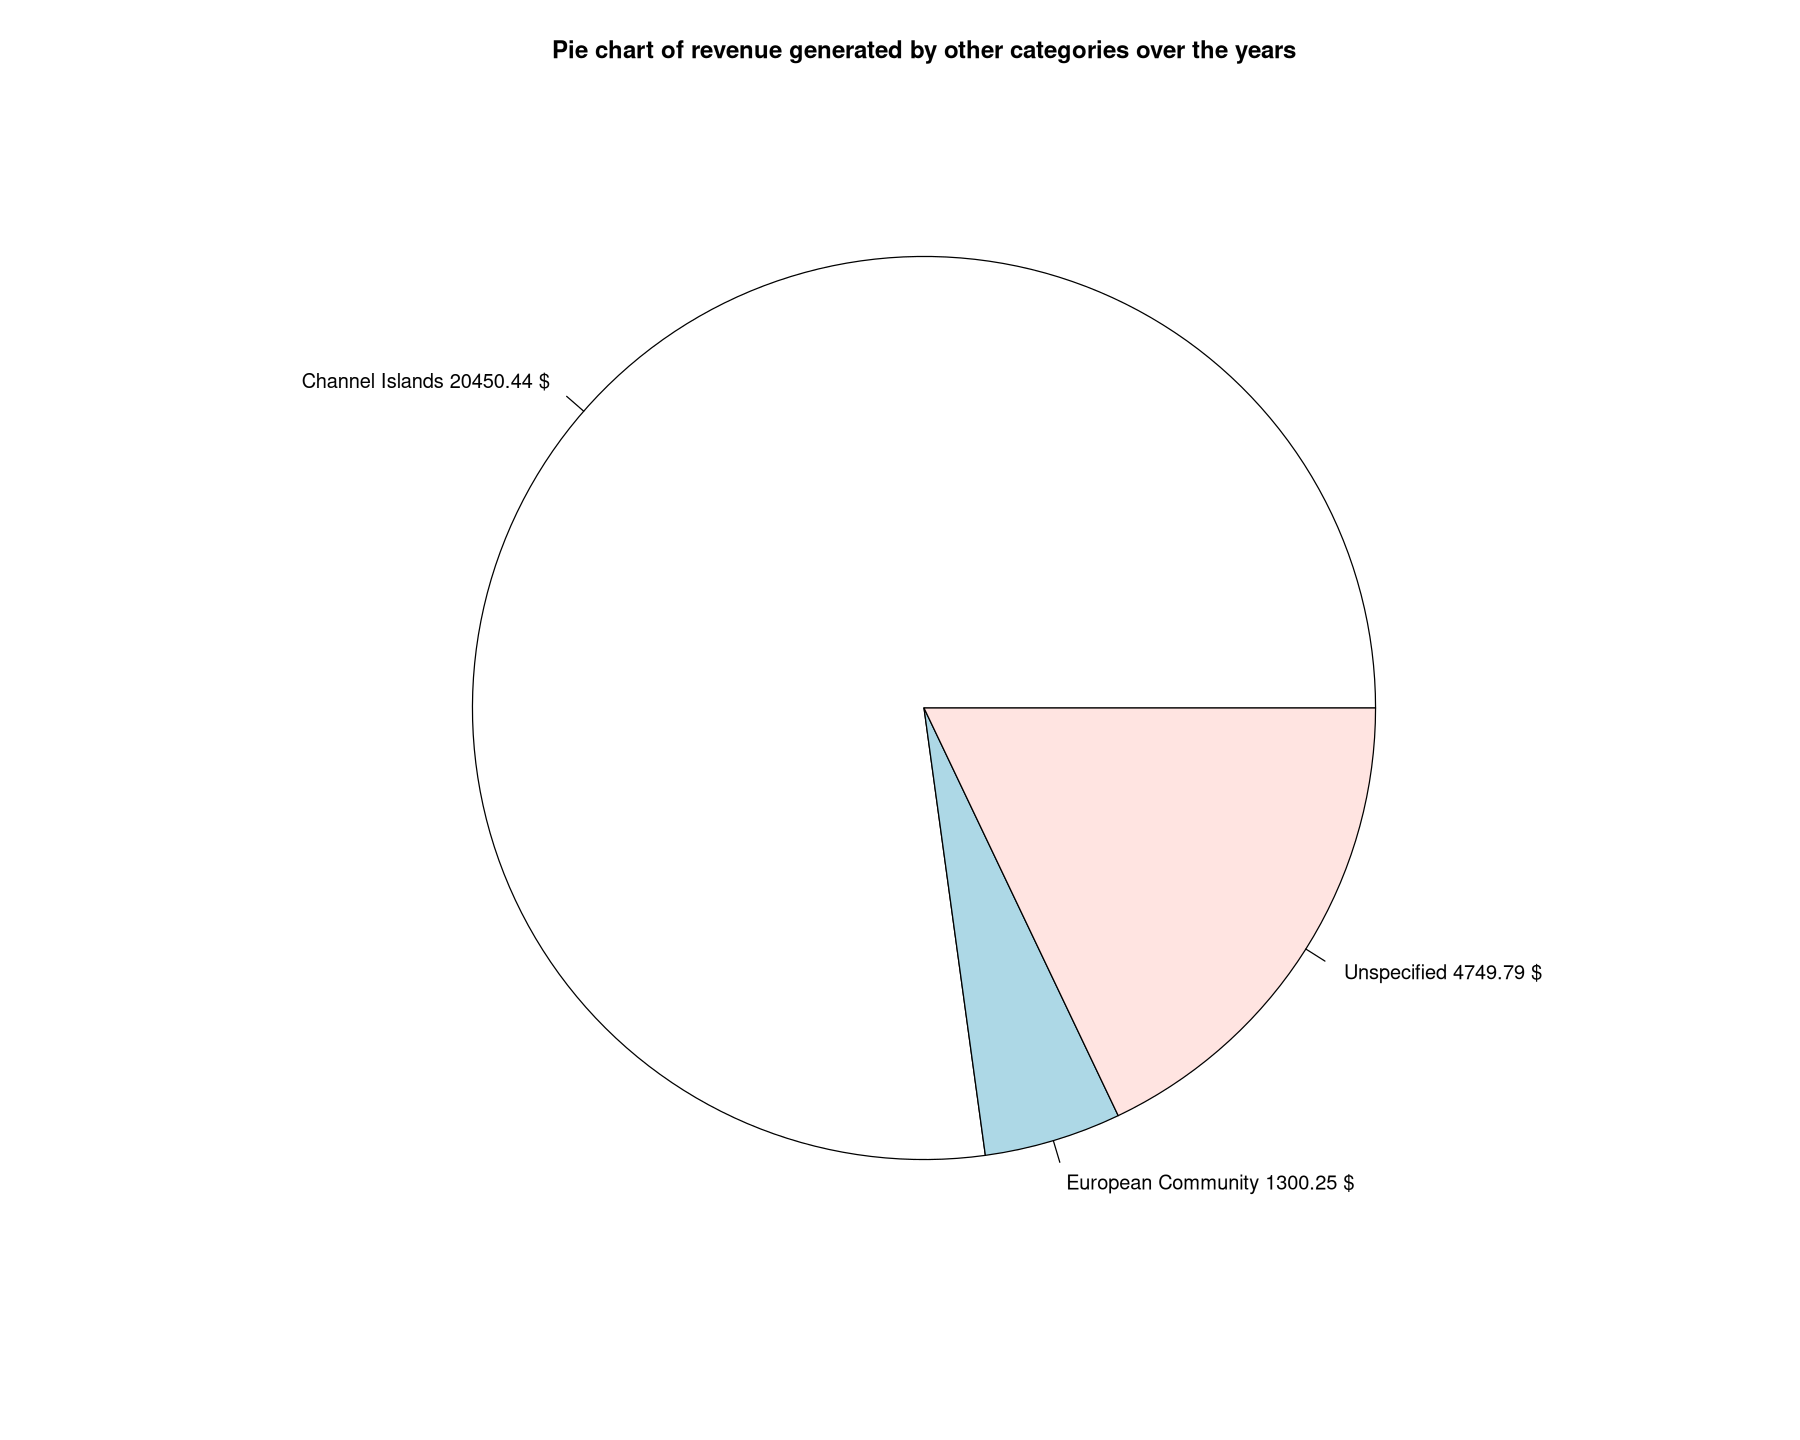

In [17]:
other_exception <- c("Unspecified", "European Community", "Channel Islands")
other_revenue <- df %>% filter(Country %in% other_exception)

group_revinue <- group_by(other_revenue, Country)
rev <- summarise(group_revinue, Rev = sum(Quantity * UnitPrice, na.rm = TRUE)) 

pie(rev$Rev, main="Pie chart of revenue generated by other categories over the years", labels=paste(rev$Country, rev$Rev, "$"))

## Customer level EDA
    .Here we want to know the 10 most frequest buyers.
    .How many items they purchased.
    .Total amount of money they spent on their shpooing.

In [18]:
library(dplyr)

# we are grouping based on CustomerId
customer <- group_by(df, CustomerID)

# Since we are summing the quanitity we are identifying based on customer that purchases more items, important to note their worth may not be more
frequency.sales <- summarize(customer, Purchase  = sum(Quantity,  na.rm = TRUE)) # ignore NA)
frequency.sales <- frequency.sales[order(frequency.sales$Purchase, decreasing=TRUE), ] # the dataset is so broken that anonymous user is a valued customer 
head(frequency.sales)


CustomerID,Purchase
<chr>,<int>
Unknown,420564
14646,196915
16446,80997
14911,80265
12415,77374
12346,74215


## Purchase of known customer
    . Frequent puschase does not mean, "High value customer" One might purchase 1$ item 100 times. The other one might pushase 5 tiems woth 10000$
    . Now from the result how can someone purchase so many items over just a year, answer maybe some might use one shopping account in family for shopping everything.
    . Other may be someone like drop shipper.

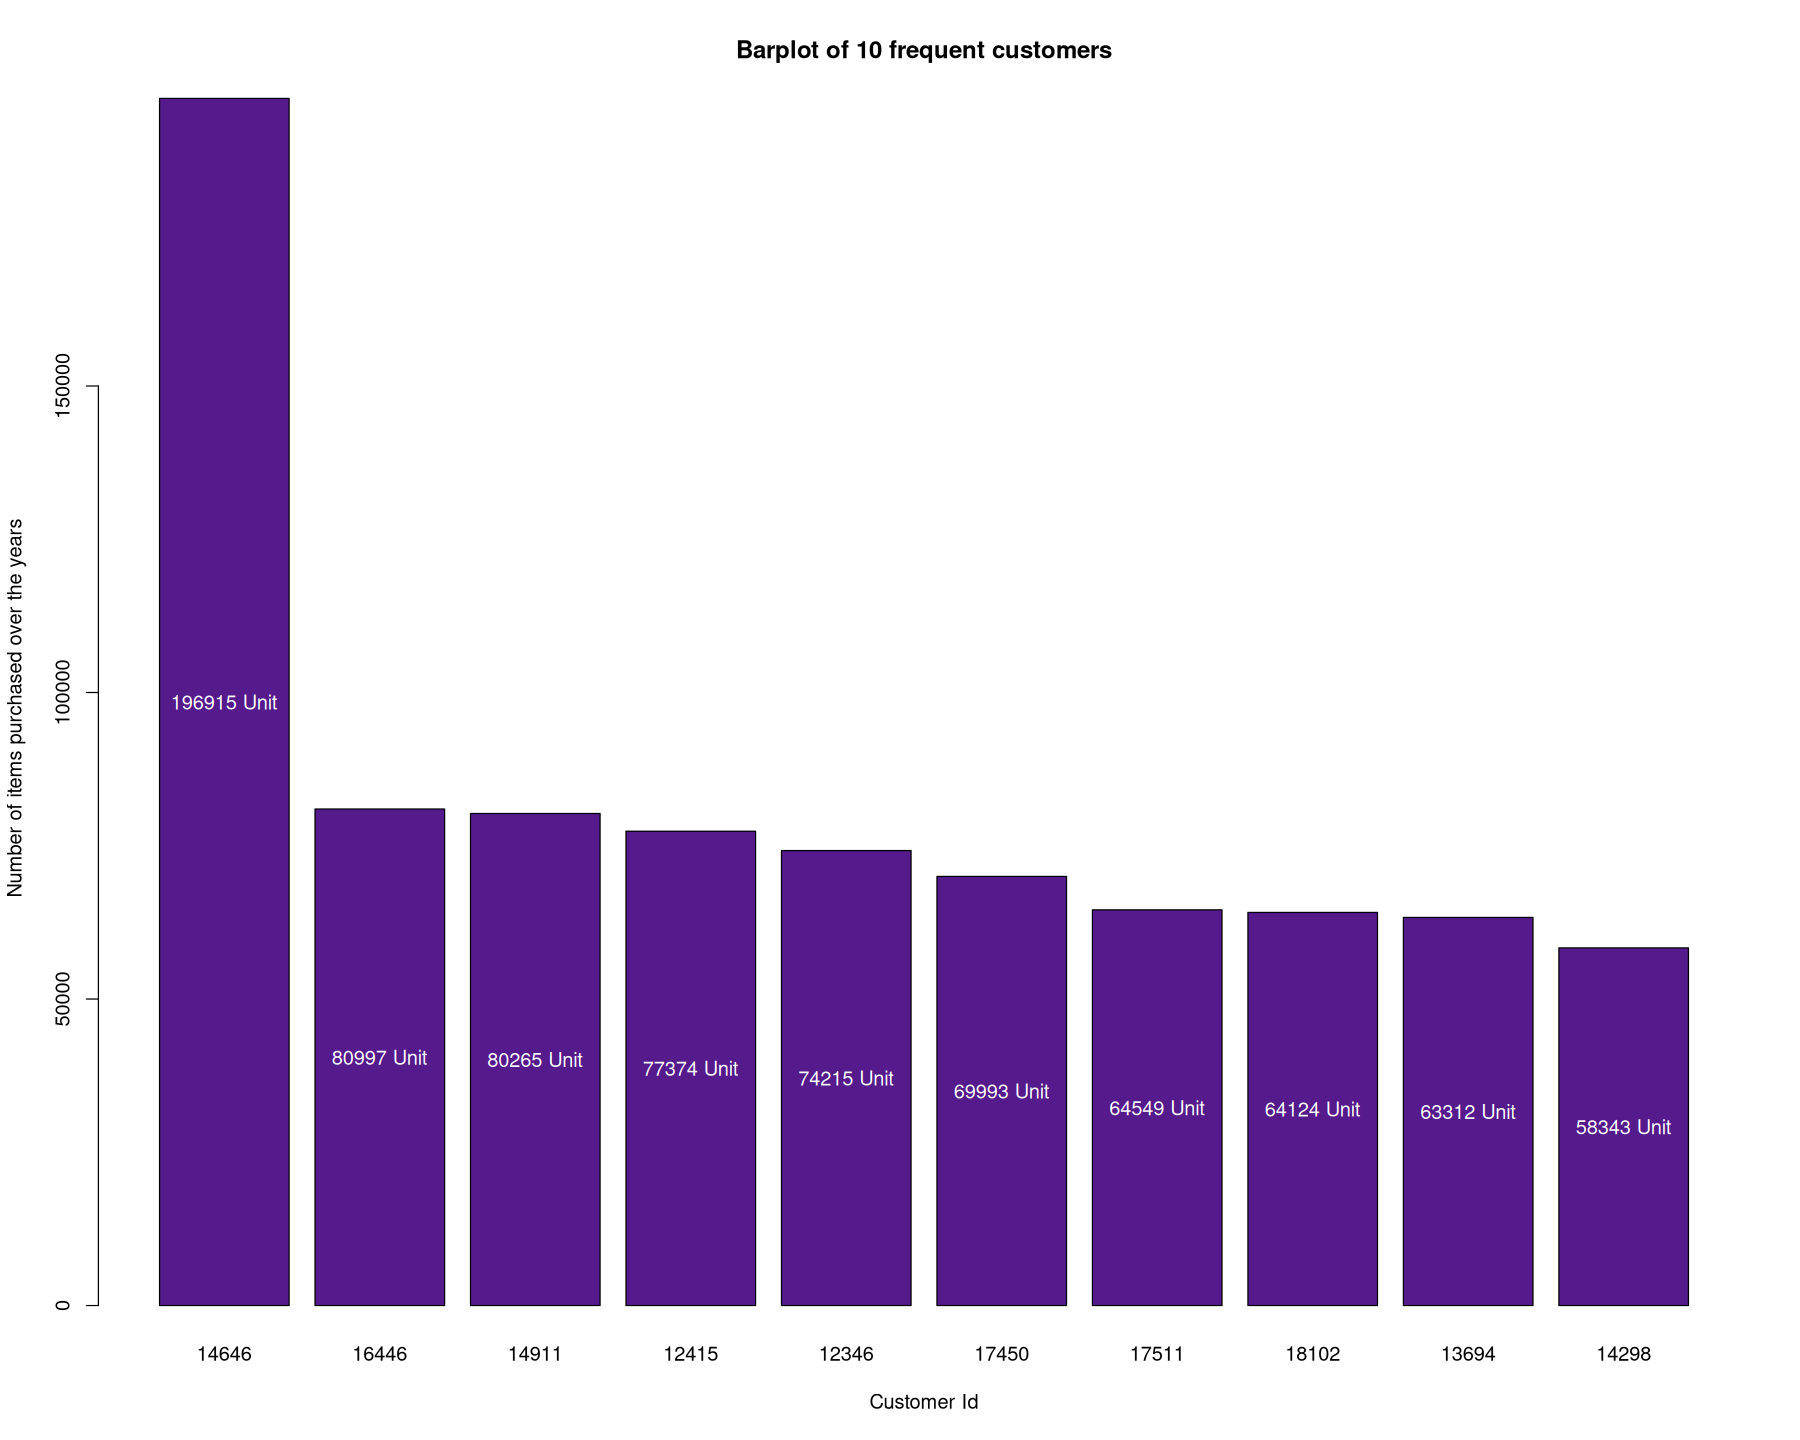

In [19]:
library(dplyr)
# if my above logic is correct then, frequency.sales is sorted, customer who purchase higest is at the top
known.customer <-  frequency.sales %>% filter(CustomerID != "Unknown")
known.customer <- head(known.customer, 10)

bp <- barplot(names.arg = known.customer$CustomerID, 
        height= known.customer$Purchase,
        main = "Barplot of 10 frequent customers",
        col="purple4",
        xlab="Customer Id",
        ylab="Number of items purchased over the years"
       )

# Labeling inside since scaling is so bad
text(
  x = bp,
  y = known.customer$Purchase / 2,  # for labeling in the middle of the bar plot
  labels = paste(known.customer$Purchase, "Unit"),
  col = "white",           
  cex = 1.0 # size of text
)

## Customer with the highest total purchase value

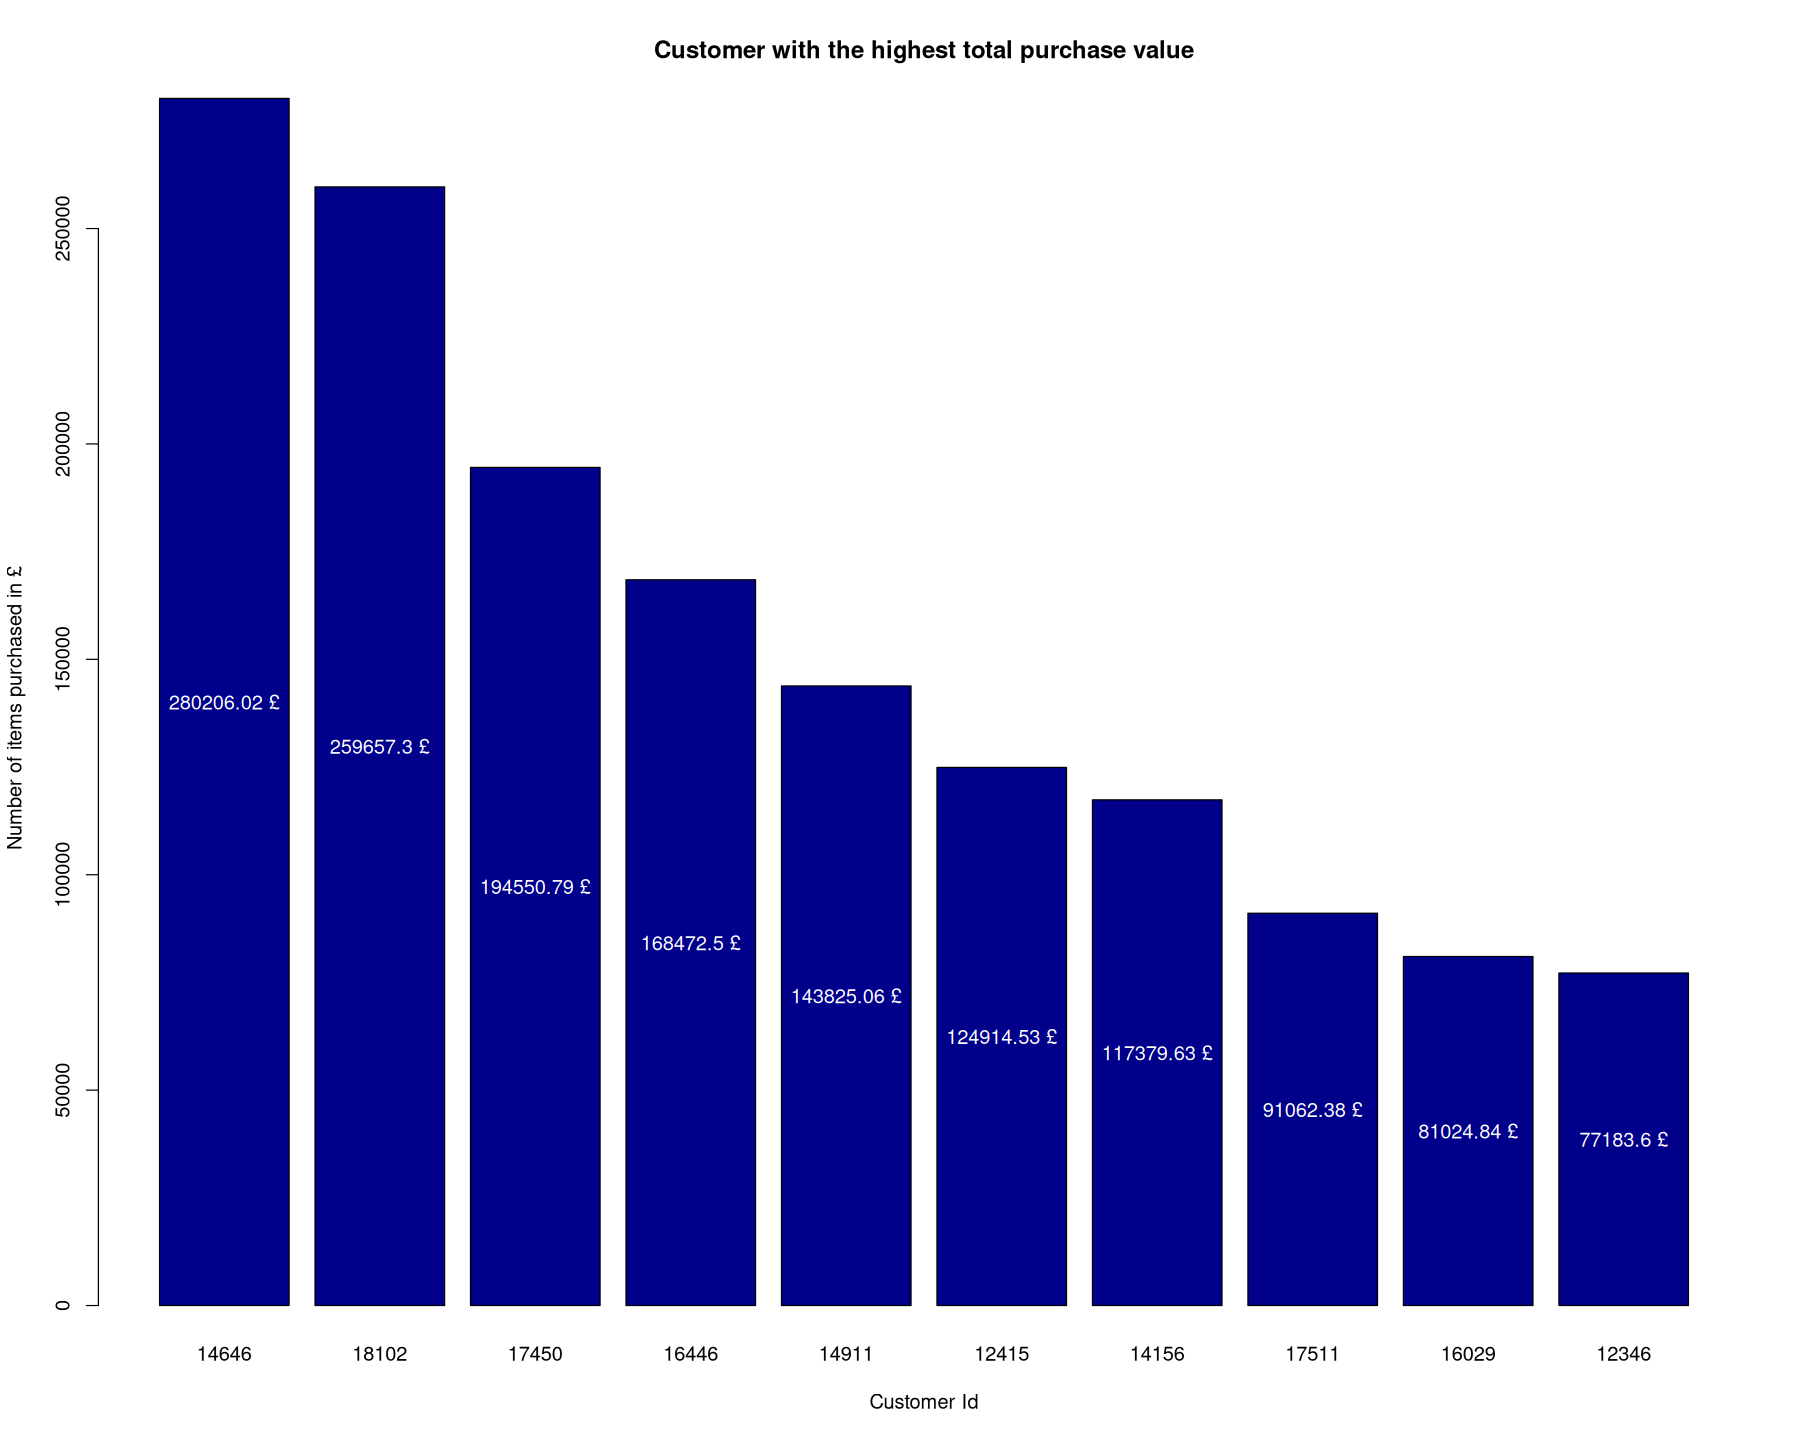

In [20]:
known.customer <-  customer %>% filter(CustomerID != "Unknown")

frequency.rev <- summarize(known.customer, Revenue = sum(Quantity * UnitPrice,  na.rm = TRUE)) # ignore NA
frequency.rev <- frequency.rev[order(frequency.rev$Revenue, decreasing=TRUE), ]
frequency.rev <- head(frequency.rev , 10)

# pasting the above barplot
bp <- barplot(names.arg = frequency.rev$CustomerID, 
        height= frequency.rev$Revenue,
        main = "Customer with the highest total purchase value",
        col="darkblue",
        xlab="Customer Id",
        ylab="Number of items purchased in £",
)

text(
  x = bp,
  y = frequency.rev$Revenue / 2,  # for labeling in the middle of the bar plot
  labels = paste(frequency.rev$Revenue, "£"),
  col = "white",           
  cex = 1.0 # size of text
)

## Cancelled or refunded orders

In [21]:
proportion_of_negative <- (  ((nrow(nv)) / (nrow(df))) * 100 ) # nv is negative value dataframe
(paste("Proportion of negative values in quantity", proportion_of_negative))

[1] "Proportion of negative values in quantity 2.00413503765299"

## 10 Most returned products
    .Most returned products
    .I don't think this data is written by the `server` of that online retail shop because data looks human writtwn, there is case mismatch.
    .OR, this maybe a computer written data from the backend, not properly structed in the database, meaninng seller who uploaded this data, had the option to write description by himself.
    .Tried my best to group based on `Description`

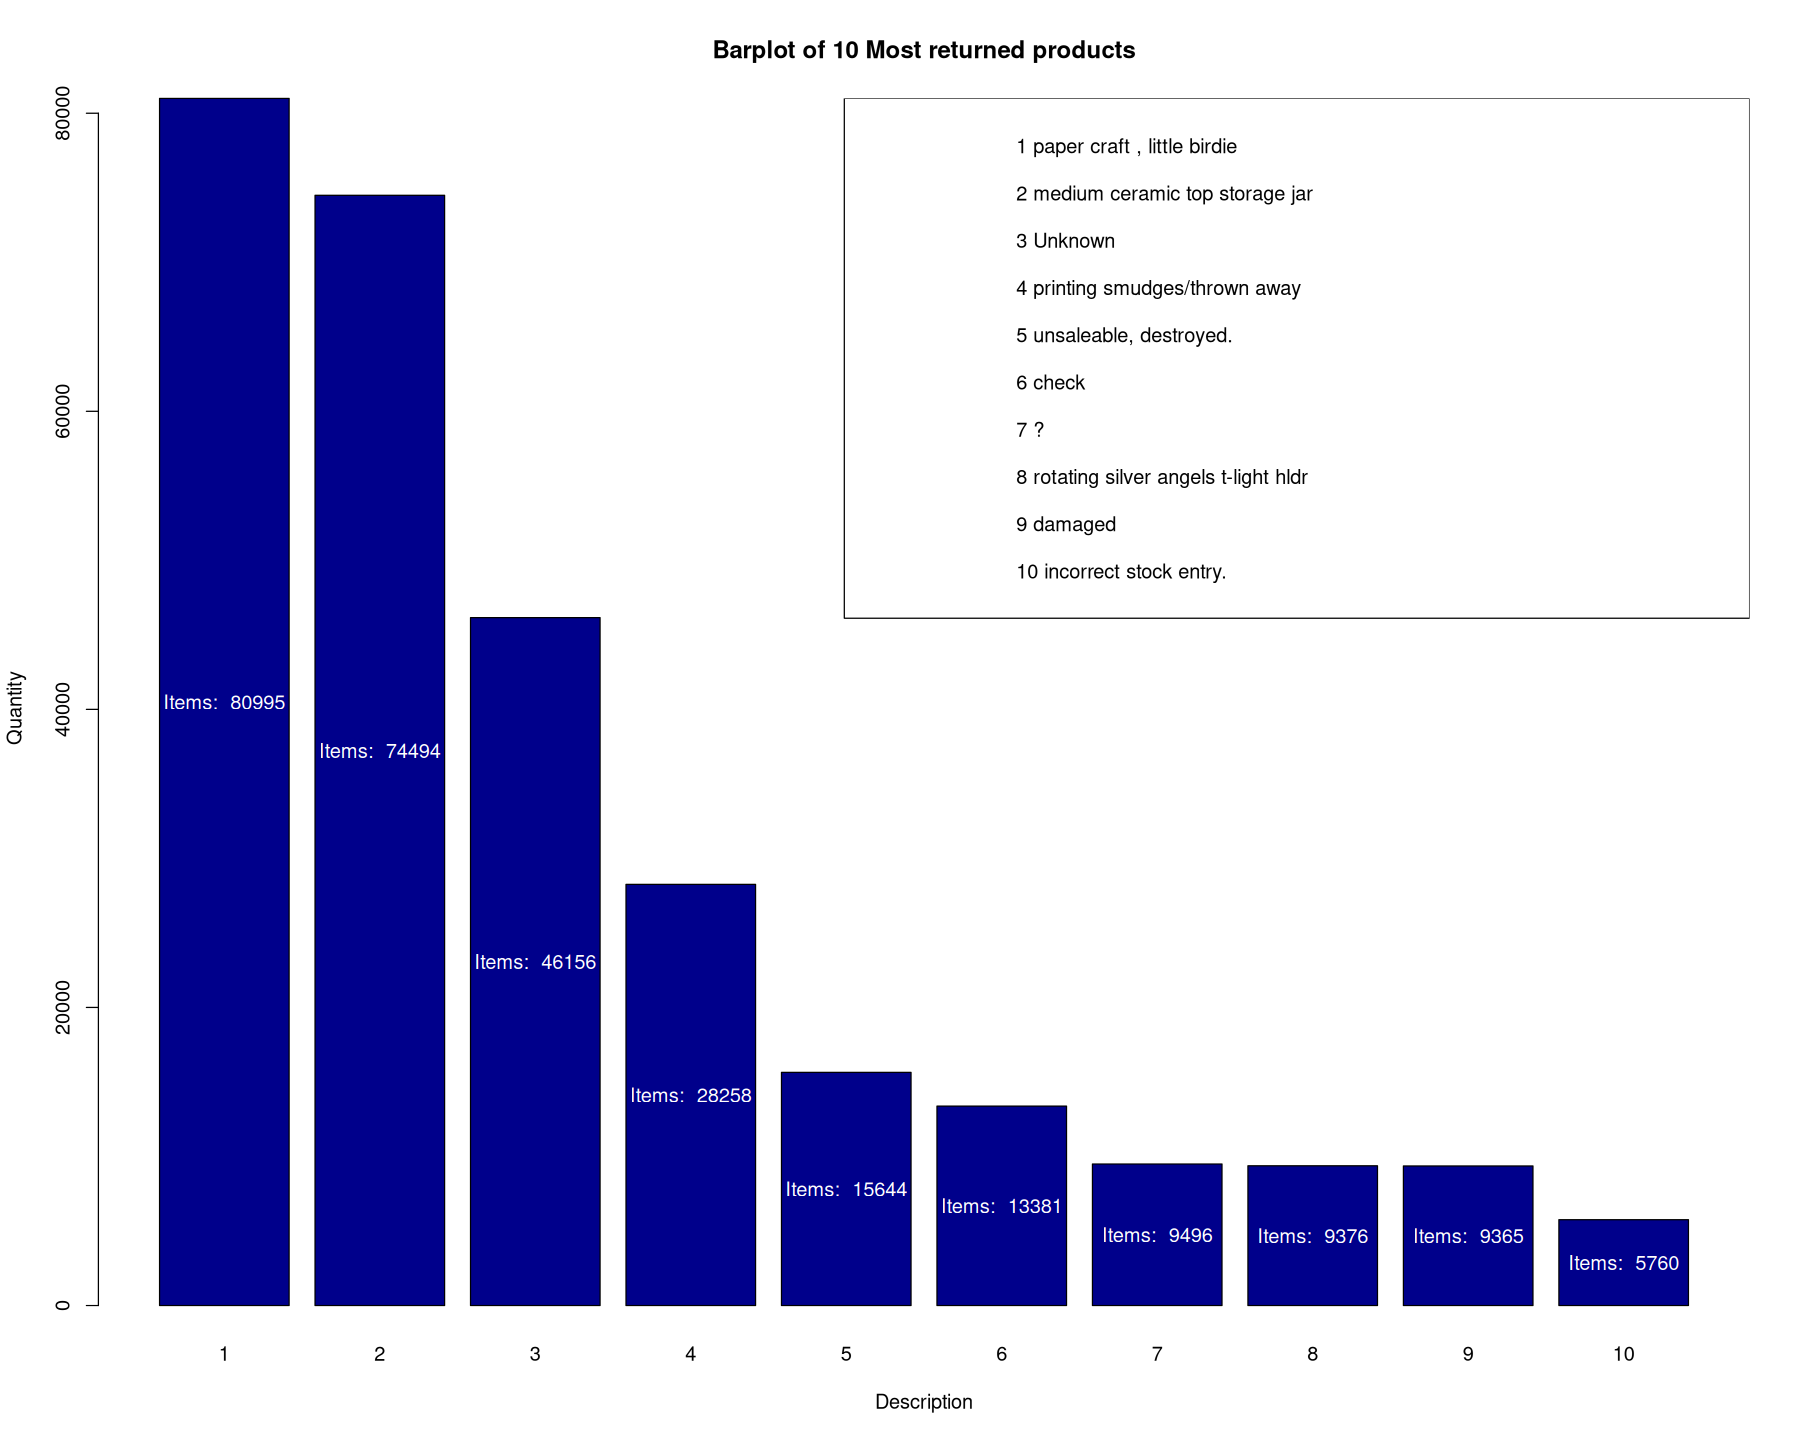

In [22]:
library(dplyr)

nv <- nv[order(nv$Quantity), ]

nv$Description <- ifelse(nv$Description == "", "Unknown", tolower(nv$Description)) 
nv$Quantity <- abs(nv$Quantity) 

g.des.net_sorted <- nv %>% 
  group_by(Description) %>%
  summarize(
    total_returned = sum(Quantity, na.rm = TRUE)
  ) 
g.des.net_sorted <- g.des.net_sorted[order(g.des.net_sorted$total_returned, decreasing = TRUE), ]
g.des.net_sorted <- head(g.des.net_sorted, 10)

sequence <- seq_along(g.des.net_sorted$total_returned)

bp <- barplot(names.arg = sequence, 
        height= g.des.net_sorted$total_returned,
        main = "Barplot of 10 Most returned products",
        col="darkblue",
        xlab="Description",
        ylab="Quantity",
)

legend("topright", 
       legend = paste(sequence, g.des.net_sorted$Description), 
       lwd = 2,
      lty = 0)        

bin.label <- paste("Items: ", g.des.net_sorted$total_returned)

text(
  x = bp,
  y = g.des.net_sorted$total_returned / 2,  # for labeling in the middle of the bar plot
  col = "white",           
  cex = 1.0, # size of text
label=bin.label,
)
# Garbage in Garbage Out (GIGO) if most of the data is trash then we cannot to anything about it.